# Clase 1: Probabilidad y Estadística para ML

Este laboratorio está pensado para:

1. Calcular medidas de tendencia central y dispersión, y ver cómo un outlier afecta a la media pero la mediana resiste.
2. Visualizar una distribución normal.
3. Calcular correlaciones entre variables de un dataset real.

## 1. Media, mediana, moda y el problema de los outliers

In [1]:
import numpy as np
import pandas as pd

sueldos = pd.Series([1, 1, 2, 2, 2, 100])  # Pensamos que son millones de pesos

print("Media:", sueldos.mean())
print("Mediana:", sueldos.median())
print("Moda:", sueldos.mode()[0])
print("Desvío estándar:", sueldos.std())

Media: 18.0
Mediana: 2.0
Moda: 2
Desvío estándar: 40.17461885320133


La media no representa bien a la mayoría de los sueldos, que están entre 1 y 2 millones. Un único valor extremo la arrastra. La mediana (2) es más resistente a outliers.

## 2. La distribución normal

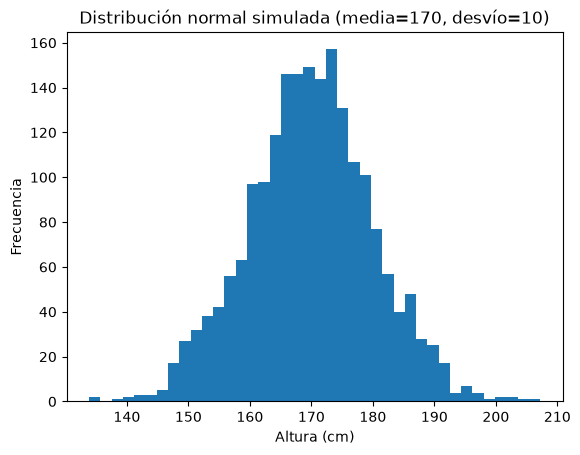

Media de la muestra: 169.89
Desvío de la muestra: 10.09


In [2]:
import matplotlib.pyplot as plt
import time

rng = np.random.default_rng(seed=int(time.time()))
muestra = rng.normal(loc=170, scale=10, size=2000)  # ej: alturas en cm

plt.hist(muestra, bins=40)
plt.title("Distribución normal simulada (media=170, desvío=10)")
plt.xlabel("Altura (cm)")
plt.ylabel("Frecuencia")
plt.show()

print("Media de la muestra:", muestra.mean().round(2))
print("Desvío de la muestra:", muestra.std().round(2))

## 3. Correlación en un dataset real

Volvemos a usar Iris para ver qué variables están más correlacionadas entre sí.

In [3]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame.drop(columns="target")
df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


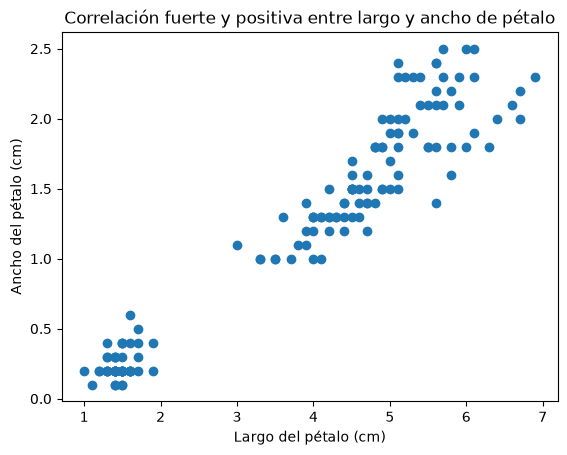

In [4]:
plt.scatter(df["petal length (cm)"], df["petal width (cm)"])
plt.xlabel("Largo del pétalo (cm)")
plt.ylabel("Ancho del pétalo (cm)")
plt.title("Correlación fuerte y positiva entre largo y ancho de pétalo")
plt.show()

## Ejercicios

**Ejercicio 1.** Agregá otros outliers a `sueldos` (por ejemplo, otro sueldo de 150) y volvé a calcular media, mediana y desvío estándar. ¿Cómo cambia cada una? ¿Qué pasa si agregamos muchos outliers?

**Ejercicio 2.** Generá una muestra normal con `scale=30` en vez de `10` (misma media). Compará el histograma con el original. ¿Qué le pasa a la "forma" de la campana?

**Ejercicio 3.** Mirando la tabla de `df.corr()`, identificar el par de variables con la correlación más baja. Luego hacer un scatter plot de ese par y confirmar visualmente qué sucede en esa situación (de paso, revisar todos los paariables).res de v. 

**Ejercicio 4.** Dos variables que están muy correlacionadas: la cantidad de heladerías abiertas en una ciudad y la cantidad de ahogamientos en piletas. ¿Hay relación de casualidad entre ellas? ¿Cuál es la variable oculta que explica a ambas?

In [9]:
# Ejercicio 1: tu código acá
import numpy as np
import pandas as pd

sueldos = pd.Series([1, 1, 2, 2, 2,3,3,1000,2000,10000])  # Pensamos que son millones de pesos

print("Media:", sueldos.mean())
print("Mediana:", sueldos.median())
print("Moda:", sueldos.mode()[0])
print("Desvío estándar:", sueldos.std())

Media: 1301.4
Mediana: 2.5
Moda: 2
Desvío estándar: 3128.073819816633


Valores ordenados: [1, 1, 2, 2, 2, 1000, 2000, 10000]
Media: 1626.0
Mediana: 2.0
Moda: 2
Desvío estándar (pandas, ddof=1): 3460.986770932739
Nota: pandas .std() es sample std (ddof=1). np.std() default es ddof=0.


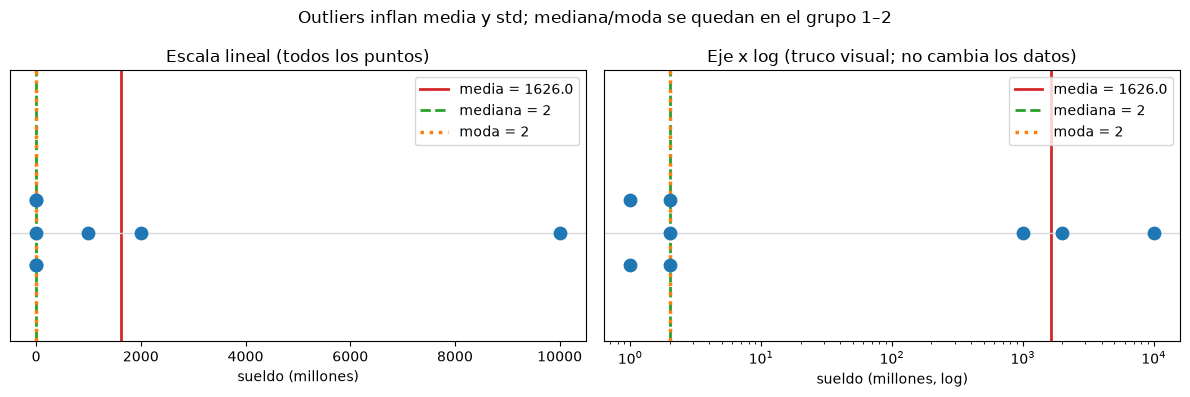

Log: comprime 1→10000 para que el grupo chico y los outliers entren en el mismo dibujo. Distancia visual ≠ diferencia en pesos. Mediana y moda coinciden en 2 (misma x, dos estilos de línea).


,n,media,mediana,moda,std (ddof=1)
base,8,1626.0,2.0,2,3460.986771
con 150,9,1462.0,2.0,2,3274.628185


150 es extremo vs 1–2, pero queda debajo de la media 1626 → la media BAJA un poco.
Mediana y moda no se mueven. std sigue enorme: manda 10000.


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Datos del Ejercicio 1 (millones de pesos)
sueldos = pd.Series([1, 1, 2, 2, 2, 1000, 2000, 10000])

print("Valores ordenados:", sorted(sueldos.tolist()))
print("Media:", sueldos.mean())
print("Mediana:", sueldos.median())
print("Moda:", sueldos.mode()[0])
print("Desvío estándar (pandas, ddof=1):", sueldos.std())
print("Nota: pandas .std() es sample std (ddof=1). np.std() default es ddof=0.")


def jitter_y(s, amp=0.18):
    """Separa puntos repetidos en el eje y (1 y 2 no se tapan)."""
    s = pd.Series(s)
    y = np.zeros(len(s), dtype=float)
    for val in s.unique():
        idx = np.flatnonzero(s.values == val)
        n = len(idx)
        y[idx] = np.linspace(-amp, amp, n) if n > 1 else 0.0
    return y


def marcar_estadisticos(ax, s, clip=None):
    media, mediana, moda = s.mean(), s.median(), s.mode()[0]
    # Media ~1626: lejos de 1–2. En histograma a veces ni se ve.
    ax.axvline(media, color="C3", ls="-", lw=2, label=f"media = {media:.1f}")
    ax.axvline(mediana, color="C2", ls="--", lw=2, label=f"mediana = {mediana:.0f}")
    ax.axvline(moda, color="C1", ls=":", lw=2.5, label=f"moda = {moda:.0f}")
    ax.legend(loc="upper right")
    return media, mediana, moda


y = jitter_y(sueldos)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# --- Izquierda: escala lineal. Se ven 1000, 2000, 10000 ---
ax = axes[0]
ax.scatter(sueldos, y, s=80, zorder=3)
marcar_estadisticos(ax, sueldos)
ax.set_title("Escala lineal (todos los puntos)")
ax.set_xlabel("sueldo (millones)")
ax.set_yticks([])
ax.set_ylim(-0.6, 0.9)
ax.axhline(0, color="0.85", lw=1)

# --- Derecha: log en x. SOLO para comprimir rango. No es log-normal. ---
ax = axes[1]
ax.scatter(sueldos, y, s=80, zorder=3)
marcar_estadisticos(ax, sueldos)
ax.set_xscale("log")
ax.set_title("Eje x log (truco visual; no cambia los datos)")
ax.set_xlabel("sueldo (millones, log)")
ax.set_yticks([])
ax.axhline(0, color="0.85", lw=1)

fig.suptitle("Outliers inflan media y std; mediana/moda se quedan en el grupo 1–2")
fig.tight_layout()
plt.show()

print(
    "Log: comprime 1→10000 para que el grupo chico y los outliers "
    "entren en el mismo dibujo. Distancia visual ≠ diferencia en pesos. "
    "Mediana y moda coinciden en 2 (misma x, dos estilos de línea)."
)

# --- Antes / después de agregar 150 ---
base = sueldos.copy()
con_150 = pd.concat([base, pd.Series([150])], ignore_index=True)


def resumen(s):
    return {
        "n": len(s),
        "media": s.mean(),
        "mediana": s.median(),
        "moda": int(s.mode()[0]),
        "std (ddof=1)": s.std(),
    }

comparacion = pd.DataFrame(
    [resumen(base), resumen(con_150)],
    index=["base", "con 150"],
)
display(comparacion)

print("150 es extremo vs 1–2, pero queda debajo de la media 1626 → la media BAJA un poco.")
print("Mediana y moda no se mueven. std sigue enorme: manda 10000.")

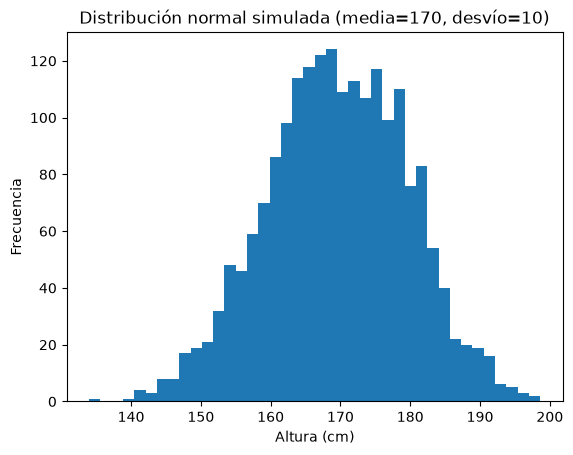

Media de la muestra: 169.56
Desvío de la muestra: 10.06


In [21]:
# Ejercicio 2: tu código acá
import matplotlib.pyplot as plt
import time

rng = np.random.default_rng(seed=int(time.time()))
muestra = rng.normal(loc=170, scale=10, size=2000)  # ej: alturas en cm

plt.hist(muestra, bins=40)
plt.title("Distribución normal simulada (media=170, desvío=10)")
plt.xlabel("Altura (cm)")
plt.ylabel("Frecuencia")
plt.show()

print("Media de la muestra:", muestra.mean().round(2))
print("Desvío de la muestra:", muestra.std().round(2))

In [22]:
import numpy as np
import matplotlib.pyplot as plt

correlaciones = df.corr()

# Nos quedamos solo con un triángulo de la tabla.
# Así no repetimos A-B y B-A, ni incluimos la diagonal.
mascara = np.triu(
    np.ones(correlaciones.shape, dtype=bool),
    k=1
)

pares = correlaciones.where(mascara).stack().sort_values()

print("Todos los pares ordenados:")
print(pares)

print("\nCorrelación numéricamente más baja:")
print(pares.index[0], "=", pares.iloc[0])

print("\nRelación más débil, más cercana a cero:")
par_debil = pares.abs().sort_values().index[0]
valor_debil = correlaciones.loc[par_debil[0], par_debil[1]]
print(par_debil, "=", valor_debil)

Todos los pares ordenados:
sepal width (cm)   petal length (cm)   -0.428440
                   petal width (cm)    -0.366126
sepal length (cm)  sepal width (cm)    -0.117570
                   petal width (cm)     0.817941
                   petal length (cm)    0.871754
petal length (cm)  petal width (cm)     0.962865
dtype: float64

Correlación numéricamente más baja:
('sepal width (cm)', 'petal length (cm)') = -0.42844010433053864

Relación más débil, más cercana a cero:
('sepal length (cm)', 'sepal width (cm)') = -0.11756978413300088


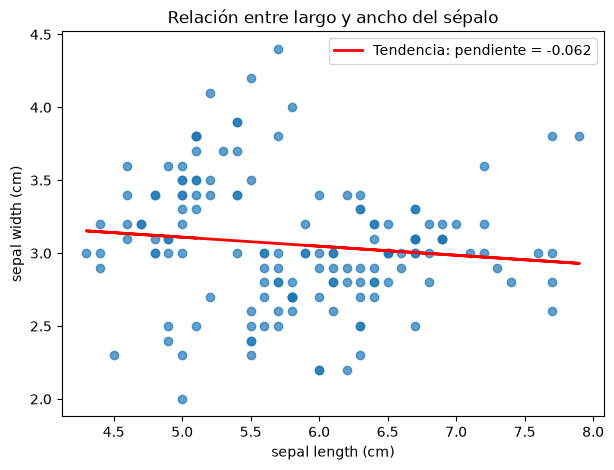

In [24]:
x = df["sepal length (cm)"]
y = df["sepal width (cm)"]

pendiente, ordenada = np.polyfit(x, y, 1)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.7)

plt.plot(
    x,
    pendiente * x + ordenada,
    color="red",
    linewidth=2,
    label=f"Tendencia: pendiente = {pendiente:.3f}"
)

plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
plt.title("Relación entre largo y ancho del sépalo")
plt.legend()
plt.show()

# La correlación entre sepal length y sepal width es negativa,
# pero muy débil (-0.118 aproximadamente). Esto significa que,
# en promedio, los sépalos más largos tienden a ser apenas más
# angostos. Sin embargo, los puntos están bastante dispersos y
# la variable sepal length no permite predecir bien sepal width.

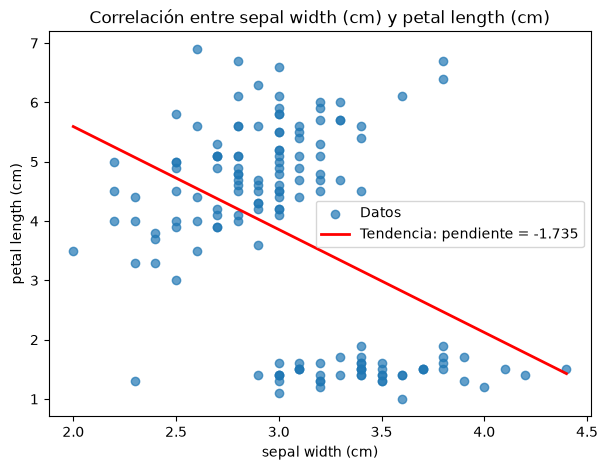

Pendiente: -1.7352215240553572
Correlación: -0.4284401043305394


In [25]:
x = "sepal width (cm)"
y = "petal length (cm)"

pendiente, ordenada = np.polyfit(df[x], df[y], 1)

orden = np.argsort(df[x])
x_ordenado = df[x].iloc[orden]
y_predicho = pendiente * x_ordenado + ordenada

plt.figure(figsize=(7, 5))

plt.scatter(
    df[x],
    df[y],
    alpha=0.7,
    label="Datos"
)

plt.plot(
    x_ordenado,
    y_predicho,
    color="red",
    linewidth=2,
    label=f"Tendencia: pendiente = {pendiente:.3f}"
)

plt.xlabel(x)
plt.ylabel(y)
plt.title(f"Correlación entre {x} y {y}")
plt.legend()
plt.show()

print("Pendiente:", pendiente)
print("Correlación:", df[x].corr(df[y]))

# La correlación entre sepal width y petal length es negativa y moderada
# (-0.428 aproximadamente). En general, cuando aumenta el ancho del
# sépalo, el largo del pétalo tiende a disminuir, aunque existe bastante
# dispersión y no todos los puntos siguen esa tendencia.

# Ejercicio 4:

### Existe una correlación entre la cantidad de heladerías y la cantidad de ahogamientos, porque ambas aumentan durante el verano. Sin embargo, no hay evidencia para afirmar que una cause la otra. La variable oculta es la temperatura o la temporada de verano: el calor aumenta el consumo de helados y también el uso de piletas, lo que aumenta la exposición al riesgo de ahogamiento. Por lo tanto, la correlación no implica causalidad.